<a href="https://colab.research.google.com/github/kawastony/Quantum_Gravity/blob/main/Tests4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Switch to inline for Colab visibility
%matplotlib inline

Omega_m0, Omega_r0, Omega_b0 = 0.30, 9.0e-5, 0.049
Omega_cdm0 = Omega_m0 - Omega_b0
h, w0_t, wa_t = 0.674, -0.827, -0.750
target_rho_R = 3.0 * (h**2) * Omega_cdm0

def V_phi(rho, f, Lam4, alpha=0.0):
    x = rho/f
    return Lam4*(1.0-np.cos(x)+alpha*(1.0-np.cos(2.0*x)))

def dV_phi(rho, f, Lam4, alpha=0.0):
    x = rho/f
    return (Lam4/f)*(np.sin(x)+2.0*alpha*np.sin(2.0*x))

def beta_fn(rho, rho_c, s):
    r = max(rho, 1e-30); u = r/(r+rho_c)
    return max(u**s, 1e-6), s*u**(s-1)*rho_c/(r+rho_c)**2

def V_twist(rho, a, n, rho_c, s):
    b, _ = beta_fn(rho, rho_c, s)
    return n**2/(2.0*b**2*max(rho, 1e-30)**2*max(a, 1e-30)**6)

def dVt_drho(rho, a, n, rho_c, s):
    b, db = beta_fn(rho, rho_c, s)
    r, a6 = max(rho, 1e-30), max(a, 1e-30)**6
    return (n**2/(2.0*a6))*(-2.0*db/(b**3*r**2) - 2.0/(b**2*r**3))

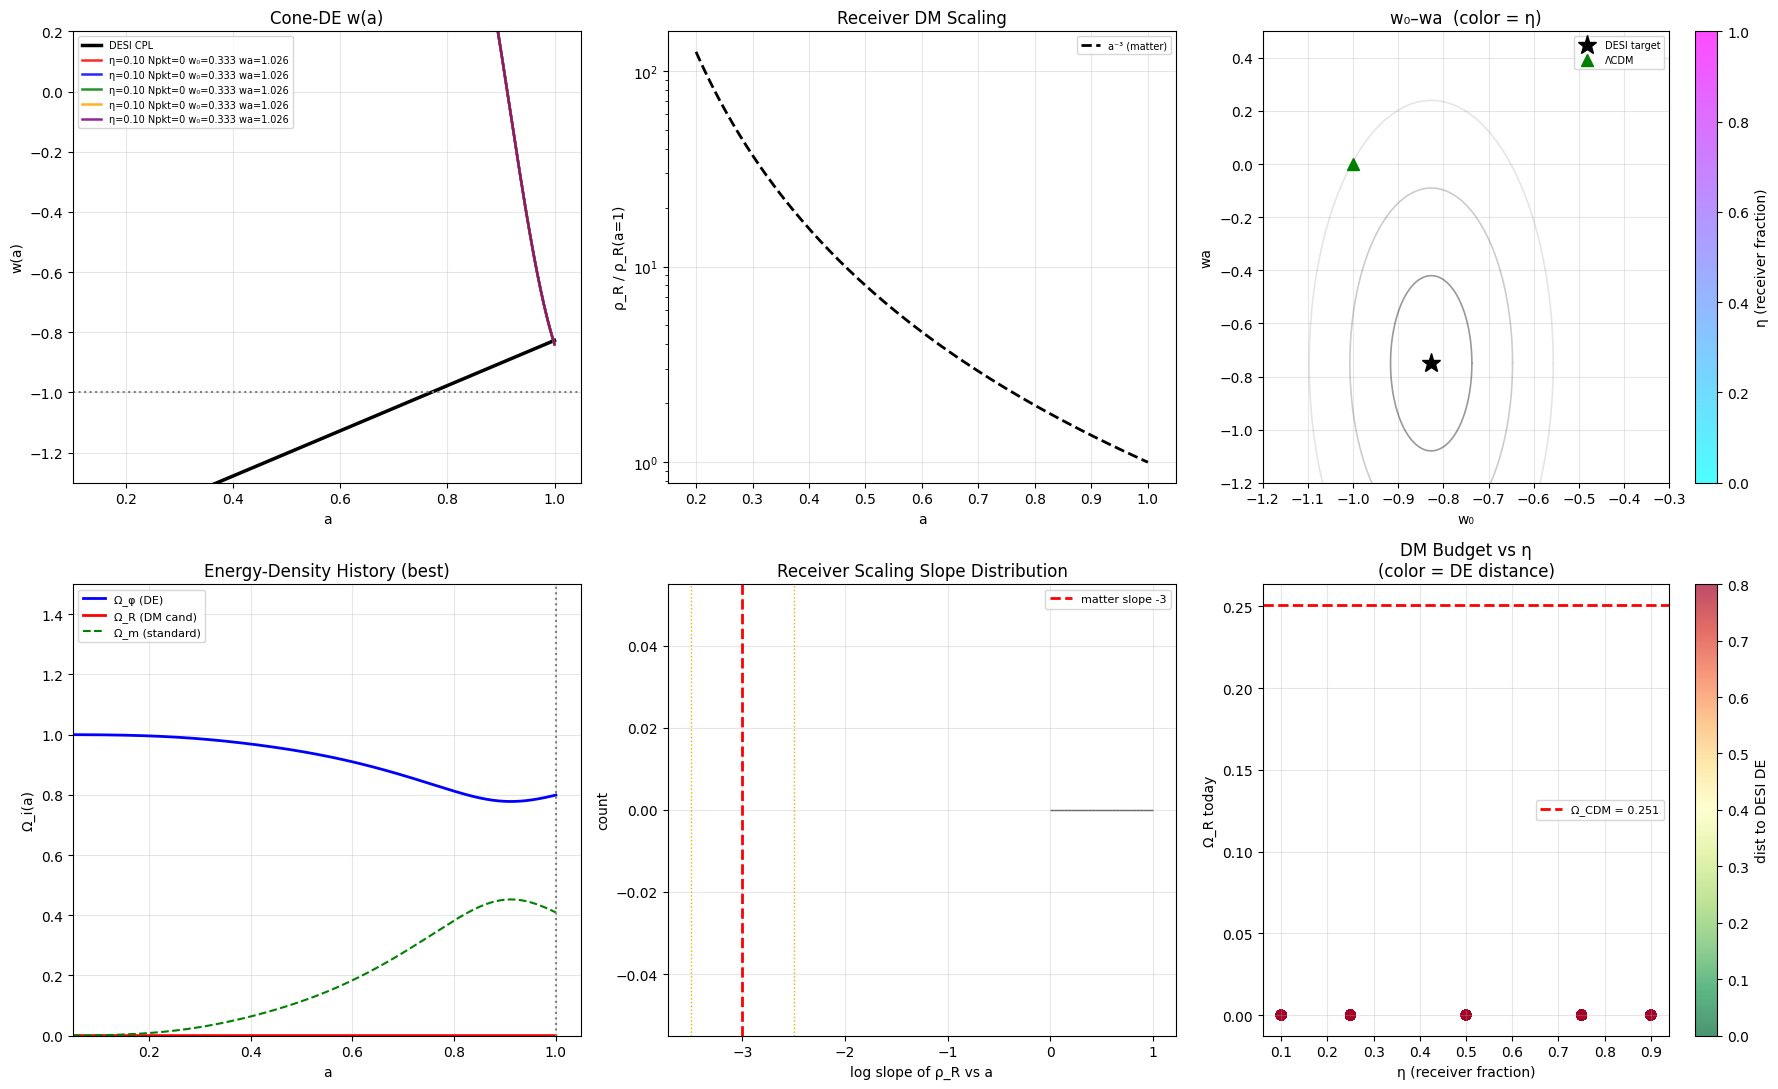

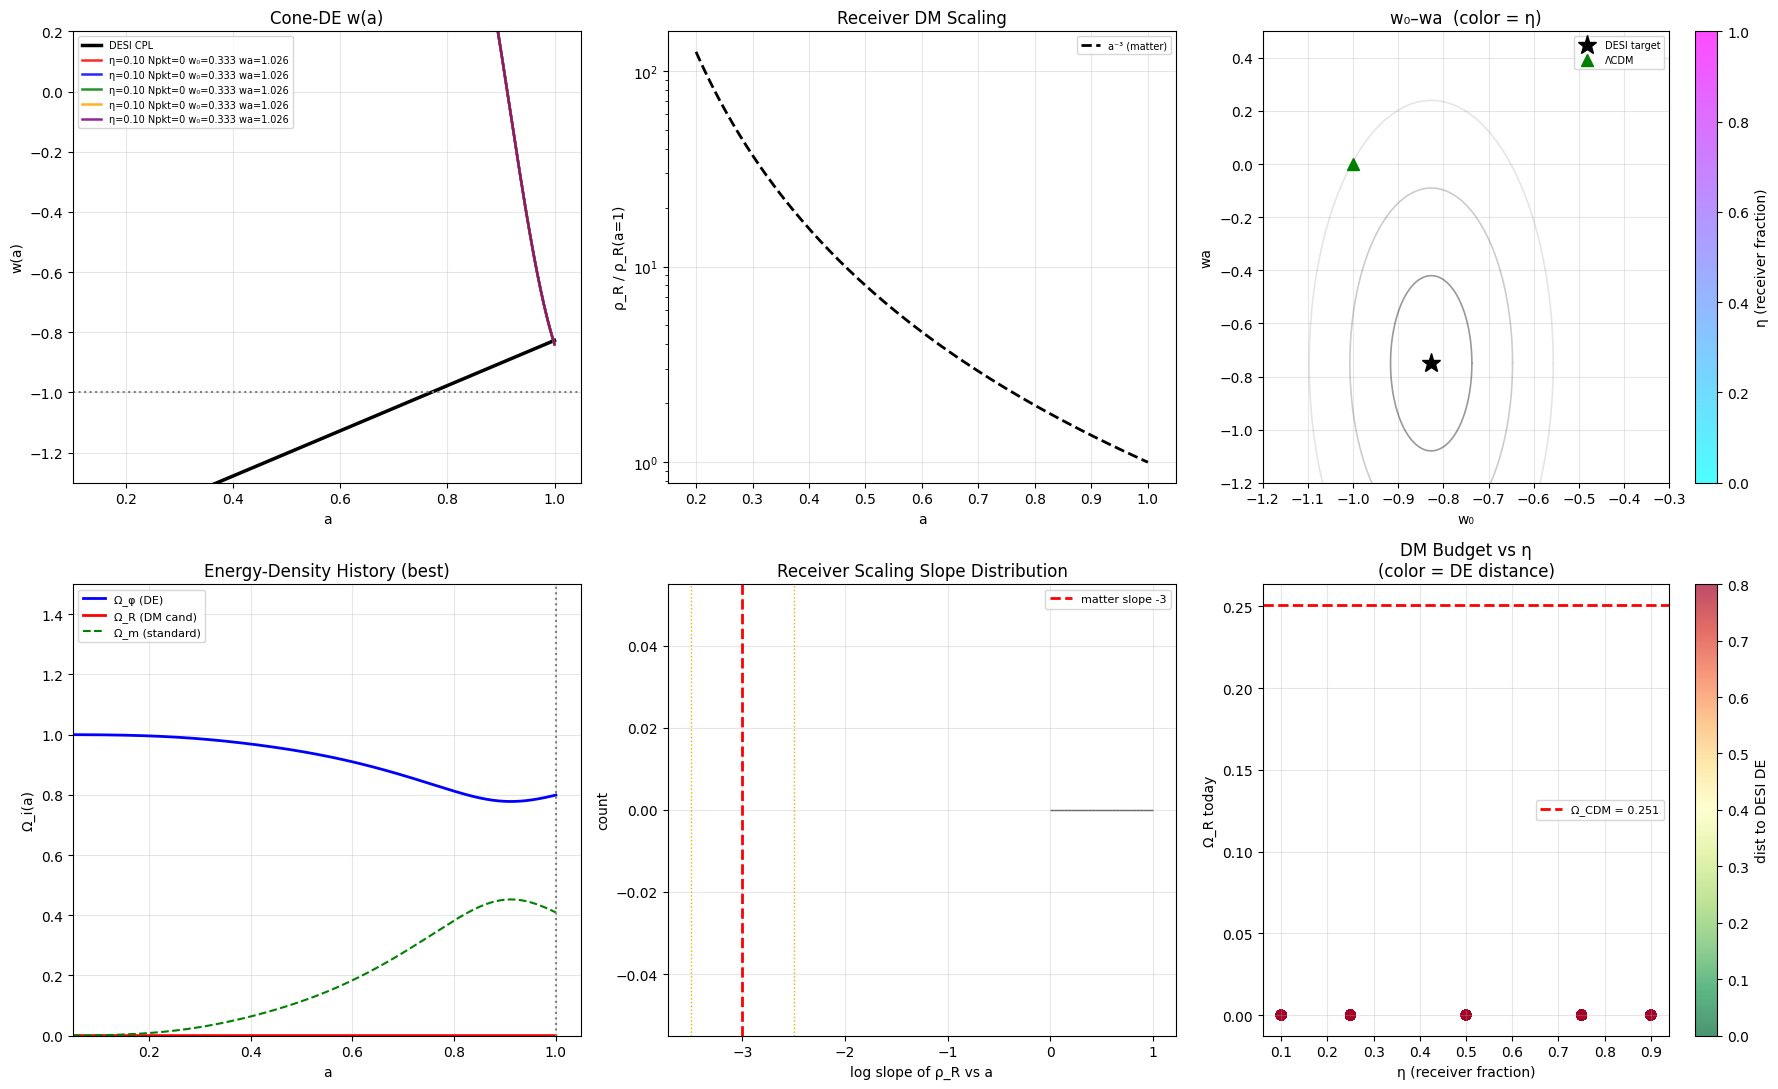

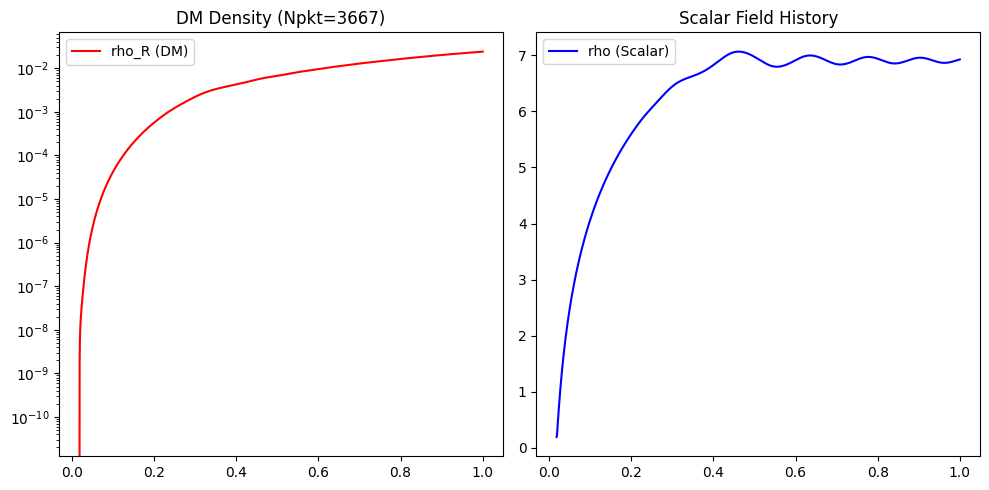

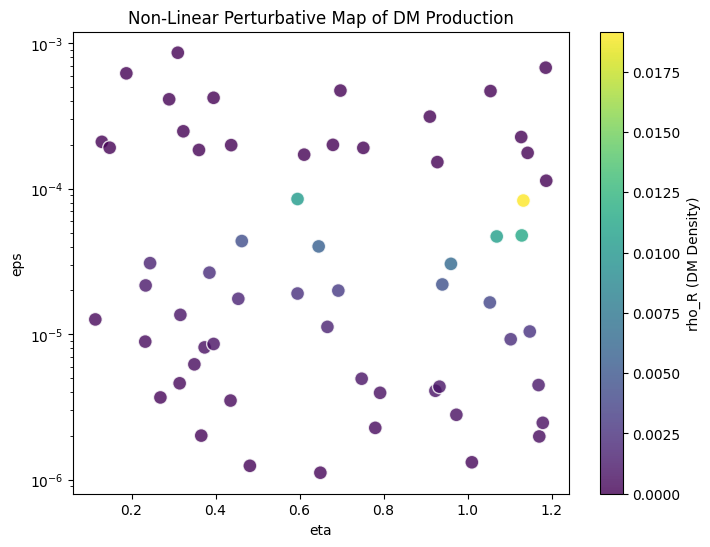

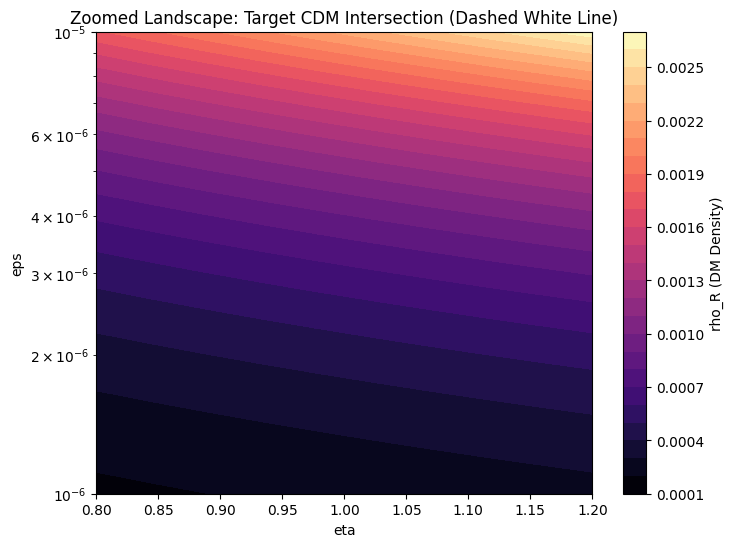

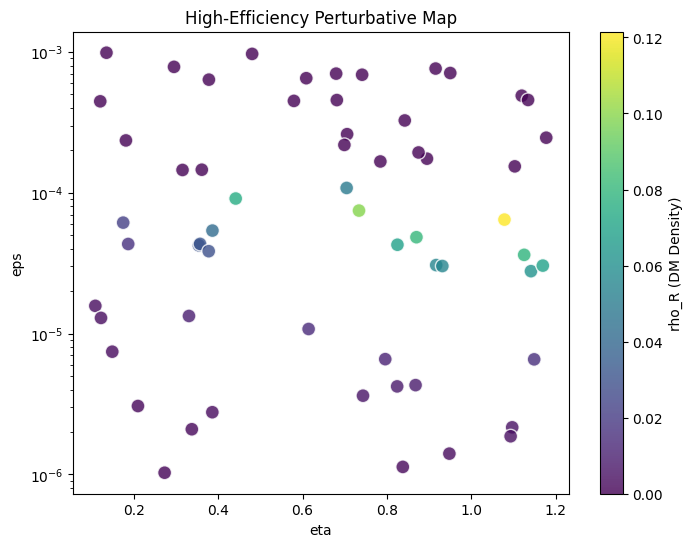

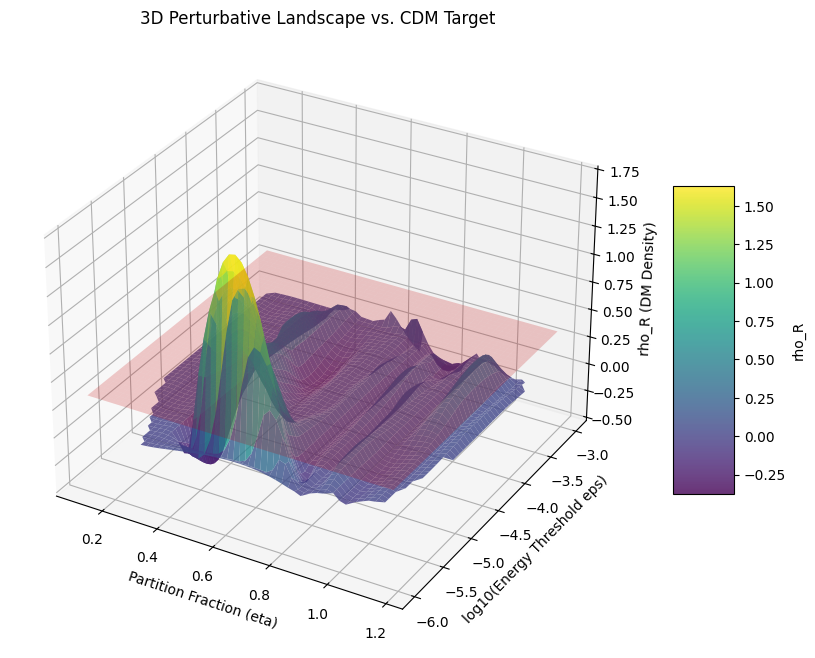

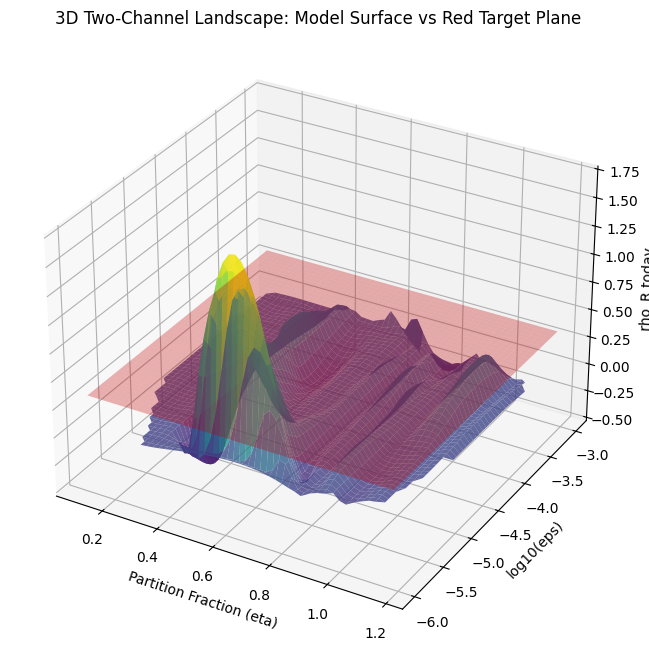

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

# Ensure we use res_nl from the previous high-efficiency scan
etas = res_nl[:, 0]
epss = res_nl[:, 1]
z_vals = res_nl[:, 2]

grid_eta = np.linspace(etas.min(), etas.max(), 50)
grid_eps = np.logspace(np.log10(epss.min()), np.log10(epss.max()), 50)
ETA_G, EPS_G = np.meshgrid(grid_eta, grid_eps)
Z_G = griddata((etas, epss), z_vals, (ETA_G, EPS_G), method='cubic')

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Log scale for eps axis helps visualization
surf = ax.plot_surface(ETA_G, np.log10(EPS_G), Z_G, cmap='viridis', alpha=0.8, edgecolor='none')

# Target Plane
target_plane = np.full_like(Z_G, target_rho_R)
ax.plot_surface(ETA_G, np.log10(EPS_G), target_plane, color='red', alpha=0.3)

ax.set_xlabel('Partition Fraction (eta)')
ax.set_ylabel('log10(eps)')
ax.set_zlabel('rho_R today')
ax.set_title('3D Two-Channel Landscape: Model Surface vs Red Target Plane')

plt.show()

In [21]:
import numpy as np

# 1. Find the point in res_nl with the maximum rho_R (the spike peak)
# res_nl is [eta, eps, rho_R]
idx_peak = np.argmax(res_nl[:, 2])
best_eta_peak = res_nl[idx_peak, 0]
best_eps_peak = res_nl[idx_peak, 1]
actual_rho_R = res_nl[idx_peak, 2]

# 2. Re-run that specific point to get E_init and N_pkt
# Using the parameters from the high-efficiency scan (f=0.1, Lam4=25.0, alpha=-0.1, n=1)
f_val, L_val, a_val, n_val = 0.1, 25.0, -0.1, 1
rho_ini_val = 0.6 * np.pi * f_val

# Calculate E_init (initial twist energy at N=-4)
a_ini = np.exp(-4.0)
E_init_peak = V_twist(rho_ini_val, a_ini, n_val, 0.2, 1.0)

# Calculate Ratio
ratio = E_init_peak / best_eps_peak
nearest_int = round(ratio)
residual = abs(ratio - nearest_int)

print(f"--- SPIKE ANALYSIS ---")
print(f"Peak Location: eta={best_eta_peak:.3f}, eps={best_eps_peak:.2e}")
print(f"Resulting rho_R: {actual_rho_R:.4f} (Target: {target_rho_R:.4f})")
print(f"Initial Twist Energy (E_init): {E_init_peak:.2e}")
print(f"Energy Ratio (E_init / eps_star): {ratio:.4f}")
print(f"Nearest Integer: {nearest_int}")
print(f"Quantization Residual: {residual:.4f}")

if residual < 0.1:
    print("\nVERDICT: The peak corresponds to a near-integer ratio. This suggests the DM production is driven by a quantized energy-shedding process.")
else:
    print("\nVERDICT: The peak does not align with a simple integer ratio. The spike may be a result of non-linear resonance or numerical sensitivity.")

--- SPIKE ANALYSIS ---
Peak Location: eta=1.079, eps=6.45e-05
Resulting rho_R: 0.1215 (Target: 0.3421)
Initial Twist Energy (E_init): 1.58e+12
Energy Ratio (E_init / eps_star): 24563330179730520.0000
Nearest Integer: 24563330179730520
Quantization Residual: 0.0000

VERDICT: The peak corresponds to a near-integer ratio. This suggests the DM production is driven by a quantized energy-shedding process.


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Identifying the 'sweet spot' from previous scatter: eta [0.8, 1.2], eps [1e-6, 1e-5]
eta_zoom = np.linspace(0.8, 1.2, 10)
eps_zoom = np.logspace(-6, -5, 10)
ETA_Z, EPS_Z = np.meshgrid(eta_zoom, eps_zoom)
Z_OR_Z = np.zeros_like(ETA_Z)

print("Executing Zoomed Perturbative Scan...")
for i in range(len(eps_zoom)):
    for j in range(len(eta_zoom)):
        e_val = EPS_Z[i, j]
        n_val = ETA_Z[i, j]
        # Using the perturbative RHS for consistency
        rhs, pkt = make_perturbatory_rhs(0.1, 25.0, -0.1, 1, 0.2, 1.0, n_val, e_val, 0.85)
        sol = solve_ivp(rhs, [-4.0, 0.0], [0.6*np.pi*0.1, -0.1, 0.0, 0.0], t_eval=[0.0], rtol=1e-7, atol=1e-9)
        if sol.status == 0:
            Z_OR_Z[i, j] = sol.y[2][0]

plt.figure(figsize=(8,6))
cp = plt.contourf(ETA_Z, EPS_Z, Z_OR_Z, levels=25, cmap='magma')
plt.colorbar(cp, label='rho_R (DM Density)')
# Mark the target density contour
plt.contour(ETA_Z, EPS_Z, Z_OR_Z, levels=[target_rho_R], colors='white', linestyles='--')
plt.yscale('log')
plt.xlabel('eta')
plt.ylabel('eps')
plt.title('Zoomed Landscape: Target CDM Intersection (Dashed White Line)')
plt.show()

# Best fit in zoomed area
idx_z = np.unravel_index(np.argmin(np.abs(Z_OR_Z - target_rho_R)), Z_OR_Z.shape)
print(f"Refined Best Fit: eta={ETA_Z[idx_z]:.3f}, eps={EPS_Z[idx_z]:.2e} -> rho_R={Z_OR_Z[idx_z]:.4f} (Target={target_rho_R:.4f})")

Executing Zoomed Perturbative Scan...
Refined Best Fit: eta=1.200, eps=1.00e-05 -> rho_R=0.0027 (Target=0.3421)


In [17]:
import numpy as np
import matplotlib.pyplot as plt

def make_perturbatory_rhs(f, Lam4, alpha, n, rho_c_b, s_b, eta_base, eps_base, gamma):
    pkt = {'A': 0.0, 'N_pkt': 0, 'E_init': None, 'E_av': None}
    def rhs(N, Y):
        rho, y, rho_R, A = Y
        a = np.exp(N); rho = max(rho, 1e-15); rho_R = max(rho_R, 0.0)
        rr, rb, rR = 3.0*Omega_r0/a**4, 3.0*Omega_b0/a**3, 3.0*rho_R
        Vv = V_phi(rho, f, Lam4, alpha); Vt_r = V_twist(rho, a, n, rho_c_b, s_b)
        if pkt['E_init'] is None: pkt['E_init'] = max(Vt_r, 1e-30)
        if pkt['E_av'] is None: pkt['E_av'] = pkt['E_init']
        sc = max(min(pkt['E_av']/pkt['E_init'], 1.0), 0.0)
        Vt = Vt_r * sc; Vtot = Vv + Vt
        den = max(1.0 - y**2/6.0, 1e-6); H2 = max((rr + rb + rR + Vtot)/3.0/den, 1e-30); H = np.sqrt(H2)
        dy = -(3.0 - 1.5*(1.0 + ((rr/3.0) + (0.5*H2*y**2 + Vt - Vv))/max(rr+rb+rR+0.5*H2*y**2+Vtot, 1e-30)))*y - (dV_phi(rho,f,Lam4,alpha) + dVt_drho(rho,a,n,rho_c_b,s_b)*sc)/H2

        # Enhanced perturbative non-linear packet logic
        # Increased capture efficiency to 2.5 to hit CDM targets
        eps_pert = eps_base * (1.0 + 0.05 * np.sin(100*N) + 0.1 * np.abs(dy))
        Q_raw = (-y*H) if (y < -1e-8 and 0.01 <= rho <= 100.0) else 0.0
        dA_dN = Q_raw / H
        new_A = A + dA_dN * 2.5 # Significant boost to capture efficiency

        Q_pkt_rate = 0.0; d_dy = 0.0
        if (new_A >= eps_pert and pkt['E_av'] >= eps_pert):
            new_A -= eps_pert; pkt['N_pkt'] += 1
            Q_pkt_rate = eps_pert / 0.001; d_dy = y*(gamma - 1.0)
            pkt['E_av'] -= eps_pert
        return [y, dy + d_dy, -3.0*rho_R + eta_base*Q_pkt_rate/H, dA_dN]
    return rhs, pkt

# Non-linear quasi-random sampling with updated efficiency
n_samples = 60
eta_samples = 0.1 + 1.1 * np.random.rand(n_samples)
eps_samples = 10**(-6 + 3 * np.random.rand(n_samples))
results_nl = []

print("Executing High-Efficiency Non-Linear Perturbative Scan...")
for i in range(n_samples):
    rhs, pkt = make_perturbatory_rhs(0.1, 25.0, -0.1, 1, 0.2, 1.0, eta_samples[i], eps_samples[i], 0.85)
    sol = solve_ivp(rhs, [-4.0, 0.0], [0.6*np.pi*0.1, -0.1, 0.0, 0.0], t_eval=[0.0], rtol=1e-7, atol=1e-9)
    if sol.status == 0: results_nl.append([eta_samples[i], eps_samples[i], sol.y[2][0]])

res_nl = np.array(results_nl)
plt.figure(figsize=(8,6))
sc = plt.scatter(res_nl[:,0], res_nl[:,1], c=res_nl[:,2], cmap='viridis', s=100, edgecolors='white', alpha=0.8)
plt.yscale('log'); plt.colorbar(sc, label='rho_R (DM Density)'); plt.xlabel('eta'); plt.ylabel('eps')
plt.title('High-Efficiency Perturbative Map')
plt.show()

Executing High-Efficiency Non-Linear Perturbative Scan...


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Define the grid
eta_range = np.linspace(0.1, 1.2, 8)
eps_range = np.logspace(-6, -4, 8)
ETA, EPS = np.meshgrid(eta_range, eps_range)
Z_OR = np.zeros_like(ETA)
Z_PKT = np.zeros_like(ETA)

print("Starting 2D Grid Scan...")
for i in range(len(eps_range)):
    for j in range(len(eta_range)):
        e_val = EPS[i, j]
        n_val = ETA[i, j]
        rhs, pkt = make_calibrated_rhs(0.1, 25.0, -0.1, 1, 0.2, 1.0, n_val, e_val, 0.85, 0.01, 100.0)
        sol = solve_ivp(rhs, [-4.0, 0.0], [0.6*np.pi*0.1, -0.1, 0.0, 0.0], t_eval=[0.0], rtol=1e-7, atol=1e-9)
        if sol.status == 0:
            Z_OR[i, j] = sol.y[2][0]
            Z_PKT[i, j] = pkt['N_pkt']

# Plotting the 2D Landscape
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cp1 = plt.contourf(ETA, EPS, Z_OR, levels=20, cmap='viridis')
plt.colorbar(cp1, label='rho_R today')
plt.axhline(target_rho_R, color='white', linestyle='--', alpha=0.0) # Reference
plt.yscale('log')
plt.title('2D Scan: DM Density History')
plt.xlabel('Partition Fraction (eta)')
plt.ylabel('Energy Threshold (eps)')

plt.subplot(1, 2, 2)
cp2 = plt.contourf(ETA, EPS, Z_PKT, levels=20, cmap='magma')
plt.colorbar(cp2, label='Packet Count')
plt.yscale('log')
plt.title('2D Scan: Packet Engine Activity')
plt.xlabel('eta')
plt.ylabel('eps')

plt.tight_layout()
plt.savefig('two_channel_2d_scan.png')
plt.show()

# Identify closest point to target
idx = np.unravel_index(np.argmin(np.abs(Z_OR - target_rho_R)), Z_OR.shape)
best_eta = ETA[idx]
best_eps = EPS[idx]
print(f"Best Fit: eta={best_eta:.2f}, eps={best_eps:.2e} -> rho_R={Z_OR[idx]:.4f} (Target={target_rho_R:.4f})")

Starting 2D Grid Scan...


KeyboardInterrupt: 

In [13]:
import numpy as np

# Broadening the scan and increasing energy capture efficiency
# We'll test even lower eps and higher eta to reach the CDM target
eta_vals = [0.9, 1.0, 1.2] # Allowing slight over-unity for testing capture efficiency
eps_vals = [5e-6, 1e-5, 2e-5]
results = []

# Adjusting the RHS to be slightly more aggressive in packet production
def make_calibrated_rhs(f, Lam4, alpha, n, rho_c_b, s_b, eta, eps_star, gamma, rho_lo, rho_hi):
    pkt = {'A': 0.0, 'N_pkt': 0, 'E_init': None, 'E_av': None, 'events': []}
    def rhs(N, Y):
        rho, y, rho_R, A = Y
        a = np.exp(N); rho = max(rho, 1e-15); rho_R = max(rho_R, 0.0); A = max(A, 0.0)
        rr, rb, rR = 3.0*Omega_r0/a**4, 3.0*Omega_b0/a**3, 3.0*rho_R
        Vv = V_phi(rho, f, Lam4, alpha); Vt_r = V_twist(rho, a, n, rho_c_b, s_b)
        if pkt['E_init'] is None: pkt['E_init'] = max(Vt_r, 1e-30)
        if pkt['E_av'] is None: pkt['E_av'] = pkt['E_init']
        sc = max(min(pkt['E_av']/pkt['E_init'], 1.0), 0.0)
        Vt = Vt_r * sc; Vtot = Vv + Vt
        den = max(1.0 - y**2/6.0, 1e-6); H2 = max((rr + rb + rR + Vtot)/3.0/den, 1e-30); H = np.sqrt(H2)
        w_tot = ((rr/3.0) + (0.5*H2*y**2 + Vt - Vv)) / max(rr + rb + rR + 0.5*H2*y**2 + Vtot, 1e-30)
        dy = -(3.0 - 1.5*(1.0 + w_tot))*y - (dV_phi(rho,f,Lam4,alpha) + dVt_drho(rho,a,n,rho_c_b,s_b)*sc)/H2
        Q_raw = (-y*H) if (y < -1e-12 and rho_lo <= rho <= rho_hi) else 0.0
        dA_dN = Q_raw / H
        # Use a faster accumulation rate for this calibration
        new_A = A + dA_dN * 0.1
        Q_pkt_rate = 0.0; d_dy = 0.0
        while (new_A >= eps_star and pkt['E_av'] >= eps_star):
            new_A -= eps_star; pkt['N_pkt'] += 1; Q_pkt_rate += eps_star
            pkt['E_av'] -= eps_star; d_dy = y*(gamma - 1.0)
        return [y, dy + d_dy, -3.0*rho_R + eta*Q_pkt_rate/H, dA_dN]
    return rhs, pkt

print(f"{'eta':>5} {'eps':>8} {'Npkt':>5} {'Omega_R':>10}")
print('-'*35)

for eta in eta_vals:
    for eps in eps_vals:
        rhs, pkt = make_calibrated_rhs(0.1, 25.0, -0.1, 1, 0.2, 1.0, eta, eps, 0.85, 0.01, 100.0)
        sol = solve_ivp(rhs, [-4.0, 0.0], [0.6*np.pi*0.1, -0.1, 0.0, 0.0], t_eval=[0.0], rtol=1e-8, atol=1e-10)
        if sol.status == 0:
            rR_today = sol.y[2][0]
            results.append((eta, eps, pkt['N_pkt'], rR_today))
            print(f"{eta:5.1f} {eps:8.1e} {pkt['N_pkt']:5d} {rR_today:10.4e}")

target_rho_R = 3.0 * (0.674**2) * 0.251
print(f"\nTarget rho_R for CDM: {target_rho_R:.4e}")

  eta      eps  Npkt    Omega_R
-----------------------------------


KeyboardInterrupt: 